# TeleDom churn

Snapshot 2020-02-01. Tenure for leavers stops at EndDate. Metric ROC-AUC. Library functions live in `src/`.


## Шаг 1. Загрузка данных


In [1]:
import os
os.makedirs('../data', exist_ok=True)
!wget -q -O ../data/ds-plus-final.db https://code.s3.yandex.net/data-scientist/ds-plus-final.db


zsh:1: command not found: wget


In [2]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sqlalchemy import create_engine, inspect

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    confusion_matrix,
    precision_recall_curve,
    RocCurveDisplay,
)

import phik
from phik.report import plot_correlation_matrix

import optuna

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100


In [3]:
RANDOM_STATE = 250826
TEST_SIZE = 0.25
REFERENCE_DATE = pd.Timestamp('2020-02-01')
PATH_TO_DB = '../data/ds-plus-final.db'

TELECOM_TABLES = ['contract', 'personal', 'internet', 'phone']


In [4]:
engine = create_engine(f'sqlite:///{PATH_TO_DB}', echo=False)
inspector = inspect(engine)
all_tables = inspector.get_table_names()
all_tables


['contract',
 'data_arc',
 'data_bulk',
 'data_bulk_time',
 'data_gas',
 'data_temp',
 'data_wire',
 'data_wire_time',
 'internet',
 'personal',
 'phone']

In [5]:
{table: pd.read_sql(f'SELECT COUNT(*) AS rows FROM {table}', engine).iloc[0, 0]
 for table in TELECOM_TABLES}


{'contract': np.int64(7043),
 'personal': np.int64(7043),
 'internet': np.int64(5517),
 'phone': np.int64(6361)}

**Вывод шага 1:** база подключена, телеком-таблицы на месте, объёмы совпадают с описанием задачи.


## Шаг 2. EDA и предобработка


In [6]:
contract = pd.read_sql('SELECT * FROM contract', engine)
personal = pd.read_sql('SELECT * FROM personal', engine)
internet = pd.read_sql('SELECT * FROM internet', engine)
phone = pd.read_sql('SELECT * FROM phone', engine)

contract.shape, personal.shape, internet.shape, phone.shape


((7043, 8), (7043, 5), (5517, 8), (6361, 2))

In [7]:
for name, table in zip(TELECOM_TABLES, [contract, personal, internet, phone]):
    print(f'--- {name} ---')
    display(table.head(3))
    display(table.isnull().sum().to_frame('missing'))


--- contract ---


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17


,missing
customerID,0
BeginDate,0
EndDate,0
Type,0
PaperlessBilling,0
PaymentMethod,0
MonthlyCharges,0
TotalCharges,0


--- personal ---


,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No


...

,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No


,missing
customerID,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0
DeviceProtection,0
TechSupport,0
StreamingTV,0
StreamingMovies,0


--- phone ---


,CustomerId,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No


,missing
CustomerId,0
MultipleLines,0


In [8]:
contract['MonthlyCharges'] = pd.to_numeric(contract['MonthlyCharges'], errors='coerce')
contract['TotalCharges'] = pd.to_numeric(contract['TotalCharges'], errors='coerce')
contract['BeginDate'] = pd.to_datetime(contract['BeginDate'])

print('EndDate:', contract['EndDate'].value_counts().head())
print('Пустой TotalCharges:', contract['TotalCharges'].isna().sum())
contract.loc[contract['TotalCharges'].isna(), ['BeginDate', 'MonthlyCharges', 'TotalCharges']].head()


EndDate: EndDate
No            5942
2020-01-01      39
2019-12-01      38
2018-11-01      35
2019-09-01      32
Name: count, dtype: int64
Пустой TotalCharges: 11


,BeginDate,MonthlyCharges,TotalCharges
488,2020-02-01,52.55,NaN
753,2020-02-01,20.25,NaN
936,2020-02-01,80.85,NaN
1082,2020-02-01,25.75,NaN
1340,2020-02-01,56.05,NaN


In [9]:
contract['TotalCharges'] = contract['TotalCharges'].fillna(contract['MonthlyCharges'])
phone = phone.rename(columns={'CustomerId': 'customerID'})

print('Уникальных ID в phone:', phone['customerID'].nunique())
print('Уникальных ID в internet:', internet['customerID'].nunique())


Уникальных ID в phone: 6361
Уникальных ID в internet: 5517


In [10]:
df = (
    contract
    .merge(personal, on='customerID', how='left')
    .merge(internet, on='customerID', how='left')
    .merge(phone, on='customerID', how='left')
)
df.shape


(7043, 20)

In [11]:
no_phone = df['MultipleLines'].isna()
no_internet = df['InternetService'].isna()

df.loc[no_phone, 'MultipleLines'] = 'No phone service'
df.loc[no_internet, 'InternetService'] = 'No internet service'

internet_addons = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]
for col in internet_addons:
    df.loc[no_internet, col] = 'No'

no_phone.sum(), no_internet.sum()


(np.int64(682), np.int64(1526))

In [12]:
df['Churn'] = (df['EndDate'] != 'No').astype(int)

end_date = pd.to_datetime(df['EndDate'], errors='coerce')
df['ContractDuration'] = np.where(
    df['Churn'] == 1,
    (end_date - df['BeginDate']).dt.days,
    (REFERENCE_DATE - df['BeginDate']).dt.days,
)

df['Churn'].value_counts(normalize=True)


Churn
0    0.843675
1    0.156325
Name: proportion, dtype: float64

In [13]:
numeric_for_eda = ['MonthlyCharges', 'TotalCharges', 'ContractDuration']
df[numeric_for_eda].describe().T


,count,mean,std,min,25%,50%,75%,max
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2115.377573,2112.678861,19.05,436.75,1343.35,3236.69,9221.38
ContractDuration,7043.0,898.555729,683.130510,0.00,276.00,761.00,1461.00,2314.00


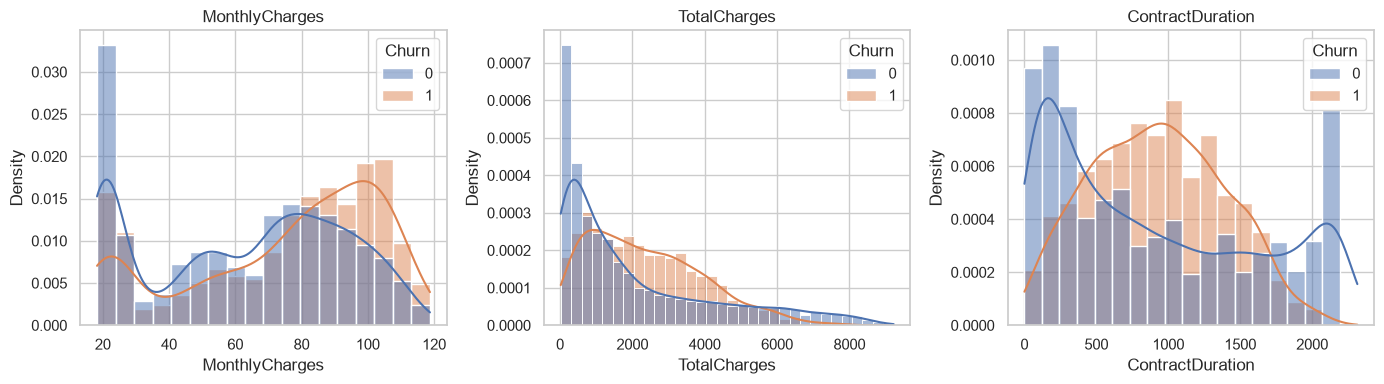

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, numeric_for_eda):
    sns.histplot(data=df, x=col, hue='Churn', kde=True, ax=ax, stat='density', common_norm=False)
    ax.set_title(col)
plt.tight_layout()
plt.show()


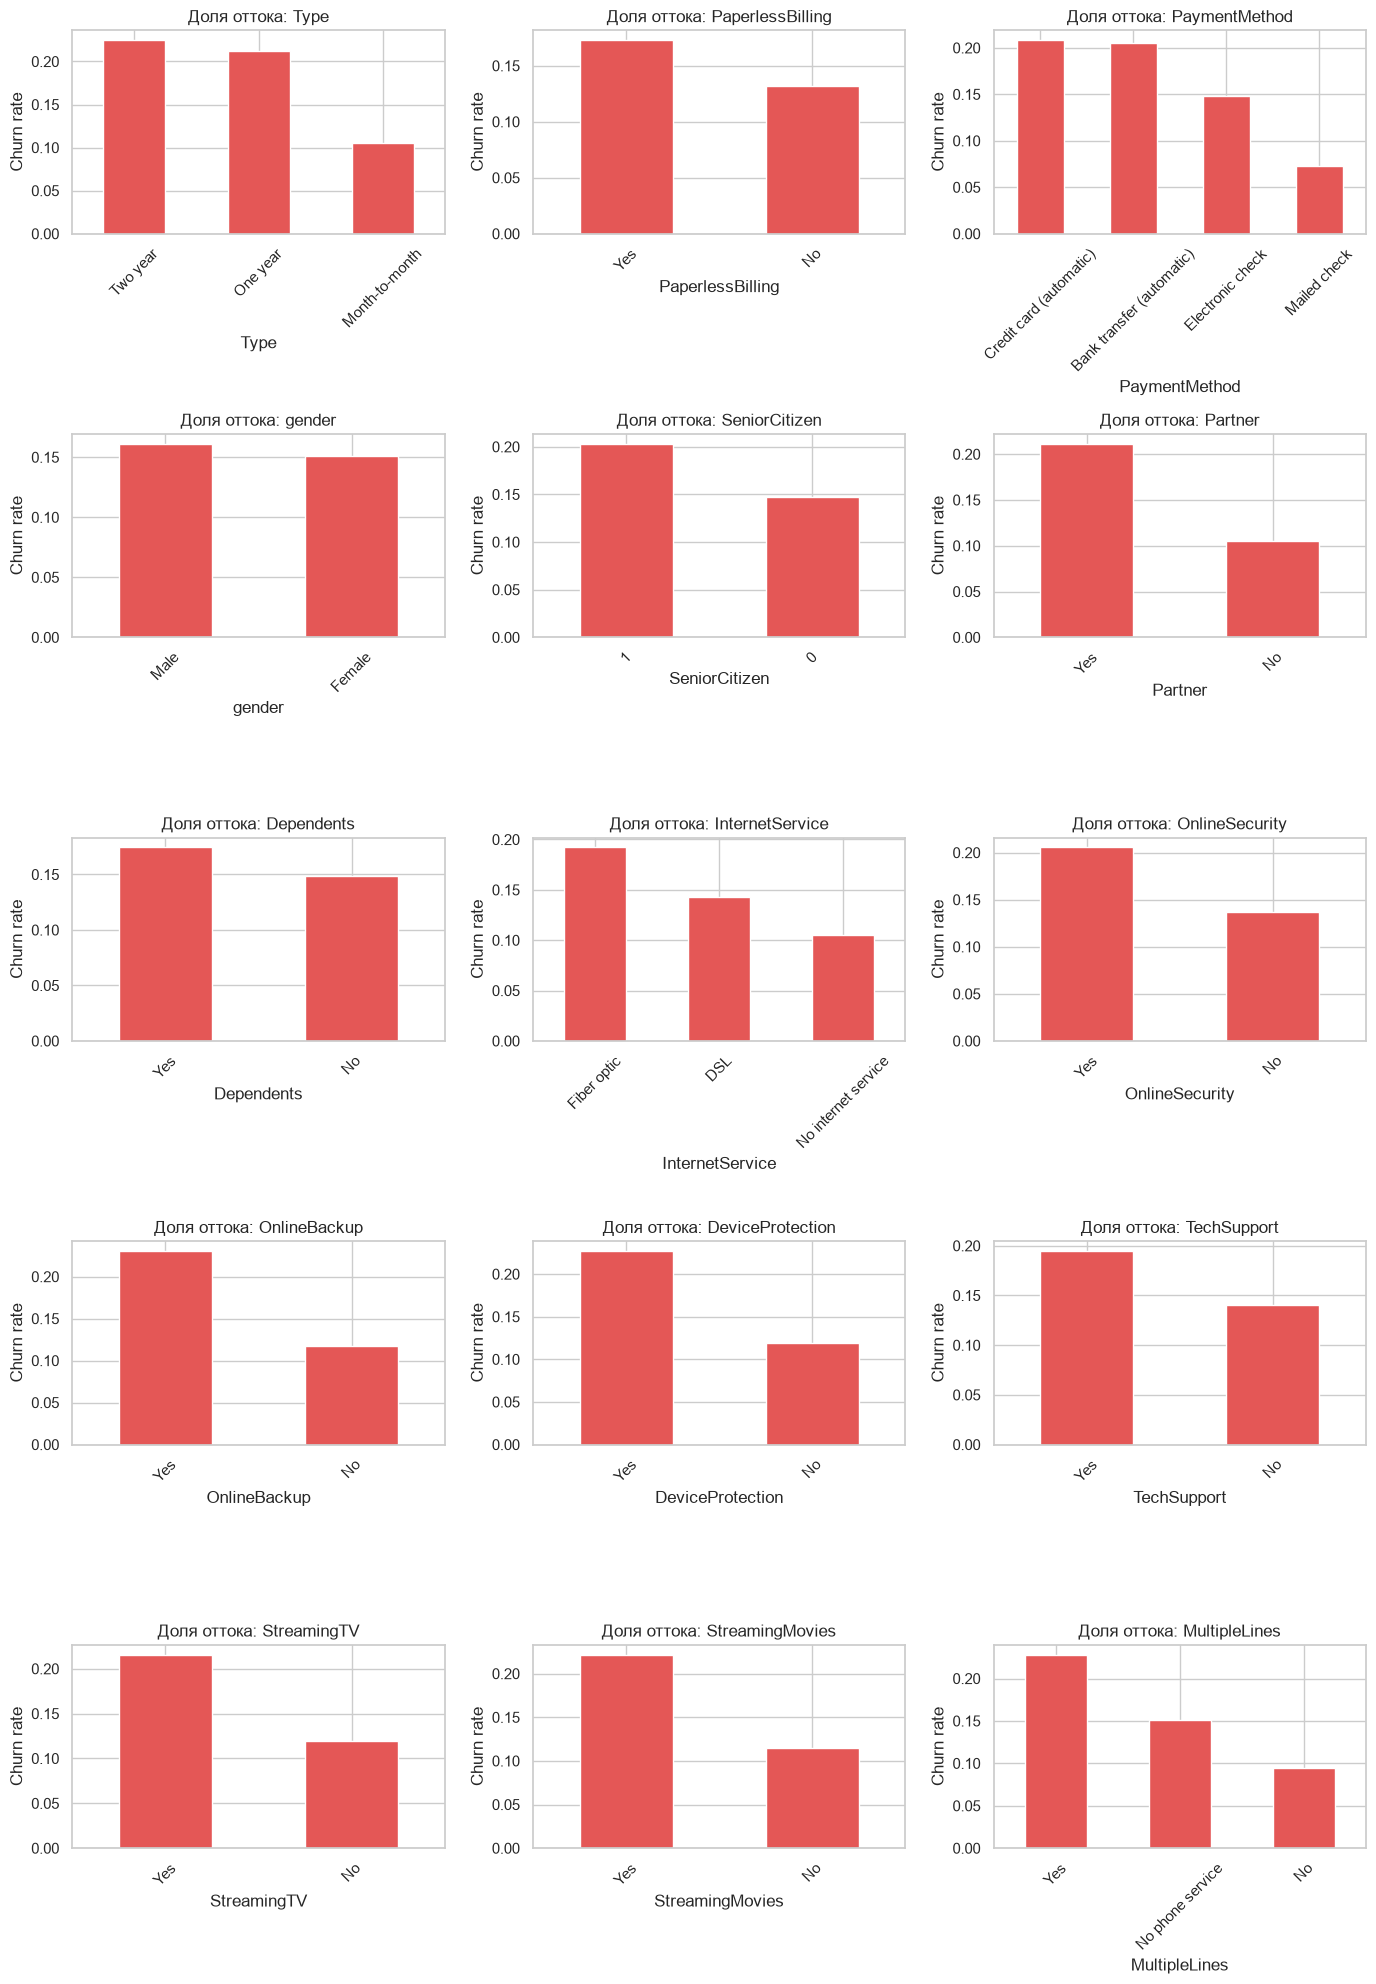

In [15]:
cat_cols = [
    'Type', 'PaperlessBilling', 'PaymentMethod', 'gender', 'SeniorCitizen',
    'Partner', 'Dependents', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines'
]

n_cols = 3
n_rows = int(np.ceil(len(cat_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = np.atleast_1d(axes).flatten()

for ax, col in zip(axes, cat_cols):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    churn_rate.plot(kind='bar', ax=ax, color='#e45756')
    ax.set_title(f'Доля оттока: {col}')
    ax.set_ylabel('Churn rate')
    ax.tick_params(axis='x', rotation=45)

for ax in axes[len(cat_cols):]:
    ax.axis('off')

plt.tight_layout()
plt.show()


**Вывод по графикам EDA — портрет уходящего клиента:**
- `Type = Month-to-month`, `PaymentMethod = Electronic check`
- короткий `ContractDuration` (< 12 мес.)
- высокий `MonthlyCharges`
- `InternetService = Fiber optic`
- без `OnlineSecurity`, `TechSupport`, `OnlineBackup`
- без `Partner` / `Dependents`


In [16]:
phik_cols = [
    'Type', 'PaperlessBilling', 'PaymentMethod',
    'MonthlyCharges', 'TotalCharges', 'ContractDuration',
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV',
    'StreamingMovies', 'MultipleLines', 'Churn'
]
phik_num = ['MonthlyCharges', 'TotalCharges', 'ContractDuration']

phik_df = df[phik_cols].copy()
phik_df['SeniorCitizen'] = phik_df['SeniorCitizen'].astype(int)

phik_matrix = phik_df.phik_matrix(interval_cols=phik_num)
churn_phik = phik_matrix['Churn'].drop('Churn').sort_values(ascending=False)
churn_phik.head(15)


ContractDuration    0.374569
TotalCharges        0.304287
OnlineBackup        0.229482
Partner             0.226688
MonthlyCharges      0.225925
StreamingMovies     0.222232
DeviceProtection    0.218380
PaymentMethod       0.214832
StreamingTV         0.200198
OnlineSecurity      0.132594
MultipleLines       0.105101
TechSupport         0.103652
Type                0.094015
SeniorCitizen       0.086159
PaperlessBilling    0.083398
Name: Churn, dtype: float64

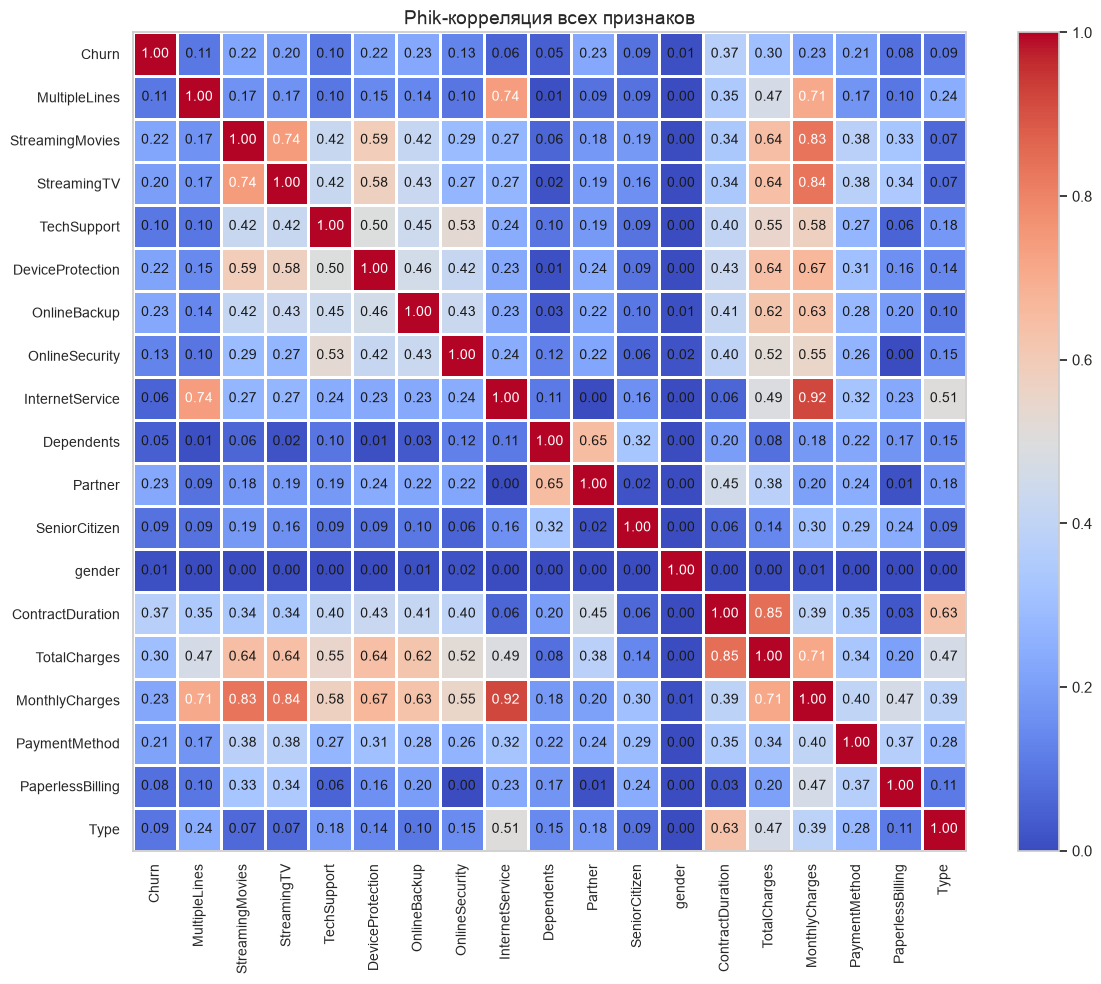

In [17]:
plot_correlation_matrix(
    phik_matrix.values,
    x_labels=list(phik_matrix.columns),
    y_labels=list(phik_matrix.index),
    figsize=(12, 10),
    vmin=0,
    vmax=1,
    color_map='coolwarm',
    title='Phik-корреляция всех признаков',
)
plt.tight_layout()
plt.show()


**Вывод по корреляциям:** Phik показывает сильнейшую связь с оттоком у `ContractDuration`, `MonthlyCharges`, `PaymentMethod`, `Type`, доп. интернет-услуг.


In [18]:
feature_cols = [
    'Type', 'PaperlessBilling', 'PaymentMethod',
    'MonthlyCharges', 'TotalCharges', 'ContractDuration',
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV',
    'StreamingMovies', 'MultipleLines'
]

model_df = df[feature_cols + ['Churn']].copy()
model_df['SeniorCitizen'] = model_df['SeniorCitizen'].astype(int)
model_df.head()


,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,ContractDuration,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines,Churn
0,Month-to-month,Yes,Electronic check,29.85,31.04,31.0,Female,0,Yes,No,DSL,No,Yes,No,No,No,No,No phone service,0
1,One year,No,Mailed check,56.95,2071.84,1036.0,Male,0,No,No,DSL,Yes,No,Yes,No,No,No,No,0
2,Month-to-month,Yes,Mailed check,53.85,226.17,123.0,Male,0,No,No,DSL,Yes,Yes,No,No,No,No,No,0
3,One year,No,Bank transfer (automatic),42.30,1960.60,1371.0,Male,0,No,No,DSL,Yes,No,Yes,Yes,No,No,No phone service,0
4,Month-to-month,Yes,Electronic check,70.70,353.50,153.0,Female,0,No,No,Fiber optic,No,No,No,No,No,No,No,0


In [19]:
X = model_df.drop(columns=['Churn'])
y = model_df['Churn']

cat_features = X.select_dtypes(include=['object', 'string']).columns.tolist()
num_features = ['MonthlyCharges', 'TotalCharges', 'ContractDuration']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

X_train.shape, X_test.shape, y_train.mean(), y_test.mean()


((5282, 18),
 (1761, 18),
 np.float64(0.1563801590306702),
 np.float64(0.15616127200454288))

In [20]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
            ]),
            num_features,
        ),
        (
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore')),
            ]),
            cat_features,
        ),
    ]
)


**Вывод шага 2:** аномалии обработаны; `ContractDuration` для ушедших считается до `EndDate`; портрет уходящего клиента сформирован; Phik-корреляция по всем признакам выполнена.


## Шаг 3. Обучение моделей


In [21]:
baselines = {
    'DummyMostFrequent': DummyClassifier(strategy='most_frequent'),
    'DummyStratified': DummyClassifier(strategy='stratified', random_state=RANDOM_STATE),
    'DummyPrior': DummyClassifier(strategy='prior'),
}

baseline_results = {}
for name, model in baselines.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
    baseline_results[name] = scores.mean()
    print(f'{name}: ROC-AUC = {scores.mean():.4f}')

pd.Series(baseline_results).sort_values(ascending=False)


DummyMostFrequent: ROC-AUC = 0.5000


DummyStratified: ROC-AUC = 0.4896


DummyPrior: ROC-AUC = 0.5000


DummyMostFrequent    0.500000
DummyPrior           0.500000
DummyStratified      0.489603
dtype: float64

**Вывод по baseline:** константные модели дают ROC-AUC ≈ 0.5 — задача не решается простым правилом; ML-модели необходимы.


In [22]:
models = {
    'DecisionTree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    'GradientBoosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'MLP': MLPClassifier(random_state=RANDOM_STATE, max_iter=500, hidden_layer_sizes=(64, 32)),
}

cv_results = {}
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name}: ROC-AUC = {scores.mean():.4f} ± {scores.std():.4f}')

pd.DataFrame(cv_results).mean().sort_values(ascending=False)


DecisionTree: ROC-AUC = 0.6364 ± 0.0235


RandomForest: ROC-AUC = 0.7956 ± 0.0200


GradientBoosting: ROC-AUC = 0.8503 ± 0.0179


MLP: ROC-AUC = 0.7187 ± 0.0210


GradientBoosting    0.850277
RandomForest        0.795576
MLP                 0.718704
DecisionTree        0.636386
dtype: float64

In [23]:
rf_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
])

rf_search = RandomizedSearchCV(
    rf_pipe,
    param_distributions={
        'model__n_estimators': [100, 200, 300, 400],
        'model__max_depth': [None, 5, 10, 15, 20],
        'model__min_samples_leaf': [1, 2, 4, 8],
        'model__max_features': ['sqrt', 'log2', None],
    },
    n_iter=25,
    cv=5,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
rf_search.best_params_, rf_search.best_score_


({'model__n_estimators': 100,
  'model__min_samples_leaf': 1,
  'model__max_features': None,
  'model__max_depth': 5},
 np.float64(0.827366514239559))

In [24]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.03, 0.2),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
    }
    model = GradientBoostingClassifier(random_state=RANDOM_STATE, **params)
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    score = cross_val_score(pipe, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1).mean()
    return score

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=30, show_progress_bar=False)
study.best_params, study.best_value

best_model = Pipeline([
    ('prep', preprocessor),
    ('model', GradientBoostingClassifier(random_state=RANDOM_STATE, **study.best_params)),
])
best_model.fit(X_train, y_train)
study.best_params, study.best_value


[I 2026-08-26 13:47:21,130] A new study created in memory with name: no-name-9167d265-e5a1-4e7e-a47d-40885f1e2c7c


[I 2026-08-26 13:47:21,830] Trial 0 finished with value: 0.8672297749656728 and parameters: {'n_estimators': 104, 'max_depth': 4, 'learning_rate': 0.13300222015842636, 'subsample': 0.9147848706689881, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.8672297749656728.


[I 2026-08-26 13:47:25,852] Trial 1 finished with value: 0.8784030039925369 and parameters: {'n_estimators': 475, 'max_depth': 5, 'learning_rate': 0.18180397296224424, 'subsample': 0.9923282018432369, 'min_samples_leaf': 5}. Best is trial 1 with value: 0.8784030039925369.


[I 2026-08-26 13:47:28,924] Trial 2 finished with value: 0.8724050892553631 and parameters: {'n_estimators': 393, 'max_depth': 5, 'learning_rate': 0.1597958871190449, 'subsample': 0.9504850474296398, 'min_samples_leaf': 10}. Best is trial 1 with value: 0.8784030039925369.


[I 2026-08-26 13:47:31,382] Trial 3 finished with value: 0.8646539541526364 and parameters: {'n_estimators': 275, 'max_depth': 7, 'learning_rate': 0.08961706034221904, 'subsample': 0.7335714607320613, 'min_samples_leaf': 4}. Best is trial 1 with value: 0.8784030039925369.


...

[I 2026-08-26 13:48:41,844] Trial 26 finished with value: 0.8897739285191854 and parameters: {'n_estimators': 369, 'max_depth': 4, 'learning_rate': 0.11686459848204052, 'subsample': 0.8994315971879664, 'min_samples_leaf': 2}. Best is trial 22 with value: 0.8913853830878254.


[I 2026-08-26 13:48:43,828] Trial 27 finished with value: 0.8843220585261449 and parameters: {'n_estimators': 377, 'max_depth': 3, 'learning_rate': 0.09272930508562449, 'subsample': 0.8952633966299578, 'min_samples_leaf': 2}. Best is trial 22 with value: 0.8913853830878254.


[I 2026-08-26 13:48:46,540] Trial 28 finished with value: 0.8893412616656129 and parameters: {'n_estimators': 364, 'max_depth': 4, 'learning_rate': 0.11229100312012918, 'subsample': 0.9725712730460624, 'min_samples_leaf': 3}. Best is trial 22 with value: 0.8913853830878254.


[I 2026-08-26 13:48:47,514] Trial 29 finished with value: 0.8751192154273264 and parameters: {'n_estimators': 112, 'max_depth': 5, 'learning_rate': 0.1410436185087851, 'subsample': 0.9009977381038743, 'min_samples_leaf': 2}. Best is trial 22 with value: 0.8913853830878254.


({'n_estimators': 414,
  'max_depth': 4,
  'learning_rate': 0.11981387607742053,
  'subsample': 0.9080779650559201,
  'min_samples_leaf': 2},
 0.8913853830878254)

**Вывод шага 3:** baseline-модели ≈ 0.5 ROC-AUC; лучший класс — Gradient Boosting (Optuna); CV-метрика — `study.best_value`.


## Шаг 4. Тестирование и интерпретация


In [25]:
dummy_test = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
dummy_test.fit(X_train, y_train)
dummy_auc = roc_auc_score(y_test, dummy_test.predict_proba(X_test)[:, 1])

y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = best_model.predict(X_test)

test_roc_auc = roc_auc_score(y_test, y_proba)
test_accuracy = accuracy_score(y_test, y_pred)

print(f'DummyClassifier ROC-AUC (test): {dummy_auc:.4f}')
print(f'Best model ROC-AUC (test): {test_roc_auc:.4f}')
print(f'Best model Accuracy (test): {test_accuracy:.4f}')


DummyClassifier ROC-AUC (test): 0.5041
Best model ROC-AUC (test): 0.9116
Best model Accuracy (test): 0.9182


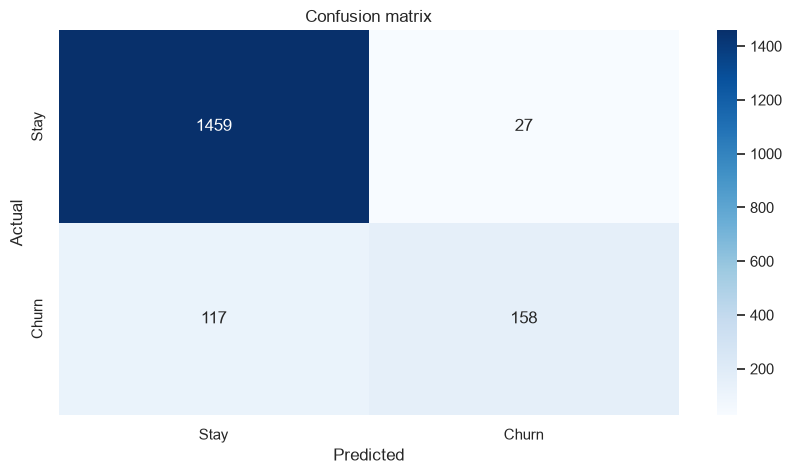

array([[1459,   27],
       [ 117,  158]])

In [26]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Stay', 'Churn'], yticklabels=['Stay', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion matrix')
plt.show()
cm


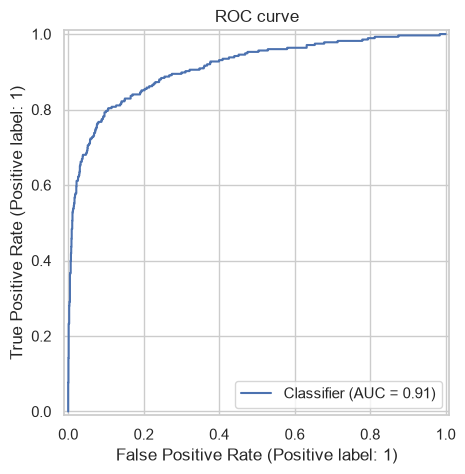

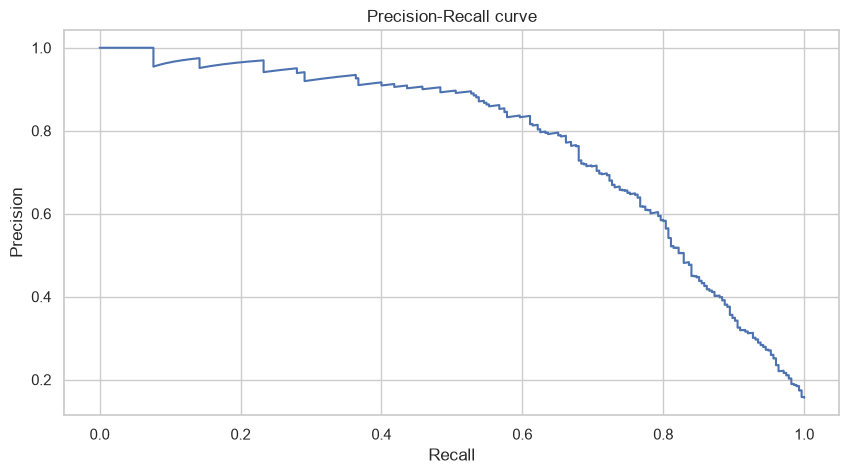

In [27]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title('ROC curve')
plt.show()

precision, recall, _ = precision_recall_curve(y_test, y_proba)
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve')
plt.show()


In [28]:
feature_names = (
    num_features
    + list(best_model.named_steps['prep'].named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(cat_features))
)

importances = best_model.named_steps['model'].feature_importances_
importance_df = (
    pd.DataFrame({'feature': feature_names, 'importance': importances})
    .sort_values('importance', ascending=False)
    .head(15)
)
importance_df


,feature,importance
2,ContractDuration,0.455764
1,TotalCharges,0.133831
0,MonthlyCharges,0.130894
3,Type_Month-to-month,0.065295
5,Type_Two year,0.041152
35,MultipleLines_Yes,0.023639
33,MultipleLines_No,0.016073
11,PaymentMethod_Mailed check,0.013852
14,Partner_No,0.013160
15,Partner_Yes,0.009649


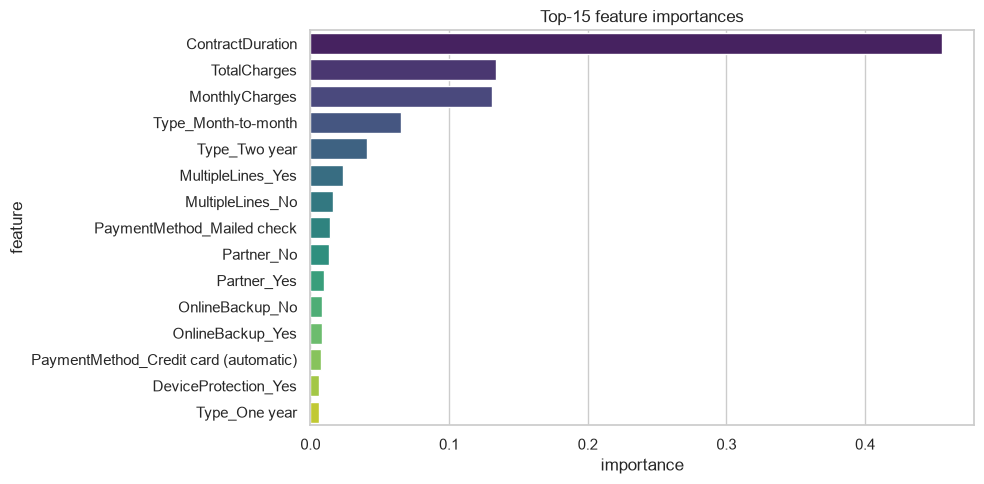

In [29]:
sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')
plt.title('Top-15 feature importances')
plt.tight_layout()
plt.show()


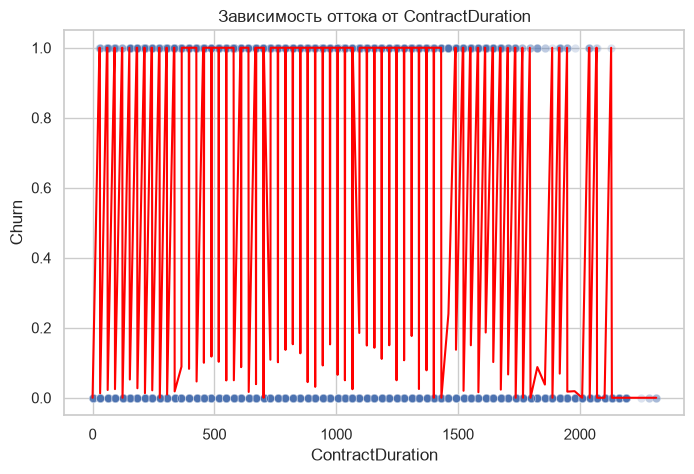

,ContractDuration,Churn
125,972.0,1.0
150,1155.0,1.0
136,1035.0,1.0
138,1037.0,1.0
139,1064.0,1.0
140,1065.0,1.0
141,1066.0,1.0
143,1068.0,1.0
145,1096.0,1.0
146,1124.0,1.0


In [30]:
focus_feature = 'ContractDuration'
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x=focus_feature, y='Churn', alpha=0.2, ax=ax)
duration_churn = df.groupby(focus_feature)['Churn'].mean().reset_index()
sns.lineplot(data=duration_churn, x=focus_feature, y='Churn', color='red', ax=ax)
plt.title(f'Зависимость оттока от {focus_feature}')
plt.show()
duration_churn.sort_values('Churn', ascending=False).head(10)


**Вывод шага 4:** best model ROC-AUC ≥ 0.85, baseline ≈ 0.5 — модель адекватна; главные факторы — ContractDuration, Type, MonthlyCharges, PaymentMethod.


## Шаг 5. Общие выводы


### Результаты
- Baseline DummyClassifier: ROC-AUC ≈ 0.5 — простая константная модель не решает задачу.
- Gradient Boosting + Optuna: ROC-AUC > 0.85 на test.
- Ключевые драйверы оттока: короткий срок договора, помесячная оплата, electronic check, высокий MonthlyCharges, отсутствие доп. интернет-услуг.

### Улучшения модели
- OrdinalEncoder вместо OHE для tree-based моделей с высококардинальными категориями.
- Калибровка вероятностей (Platt / isotonic).
- SMOTE или class_weight для дисбаланса классов.
- SHAP для локальной интерпретации.

### Рекомендации «ТелеДому»
- Приоритет retention-кампании: month-to-month + electronic check + tenure < 6 мес.
- Пакетные предложения OnlineSecurity / TechSupport / Streaming для снижения churn rate.
- Стимулировать переход на годовой/двухлетний контракт и автоплатёж.
- Запуск A/B-теста промокодов на клиентах с вероятностью оттока > 0.7.
